In [1]:
# install dependencies for local run
!pip install geopandas openpyxl matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ---------- ----------------------------- 2.1/8.3 MB 10.8 MB/s eta 0:00:01
   --------------------------- ------------ 5.8/8.3 MB 14.6 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 15.4 MB/s  0:00:00
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ---------------------------------------- 2.3/2.3 MB 20.7 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   -------------------------- ------------- 4.7/7.2 MB 22.6 MB/s eta 0:00:01
   ---------------------------------------- 7.2/7.2 MB 21.0 MB/s  0:00:00

   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ---- ----------------------------------- 1/9 [pillow]
   ------------- -------------------------- 3/9 [fontt

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [2]:
# import libraries
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
import os
# Set working directory to the Emily folder where the data files live
os.chdir(os.path.dirname(os.path.abspath("__file__")))
print("Working directory:", os.getcwd())

Working directory: C:\Users\brian\ABT182\Emily\Emily


In [4]:
# load data — update paths to match your environment
# Google Colab: use /content/myGdrive/MyDrive/ABT 182/project/
# Local: use relative paths like "Emily/Emily/"
df2014 = pd.read_csv("2014.csv")
df2016 = pd.read_csv("2016.csv")
df2018 = pd.read_csv("2018 - 2018.csv")
df2019 = pd.read_csv("2019 - 2019.csv")
df2020 = pd.read_csv("2020 - 2020.csv")
df2021 = pd.read_csv("2021.csv")
df2022 = pd.read_csv("2022.csv")

# Filtering ALL grapes + Calculating aggregate yield (tons/acre) by county
# Uses total Production (tons) for all grape varieties per county,
# divided by vineyard acreage per county from DWR data.

In [5]:
# filter ALL grapes (wine, raisin, table, unspecified) — exclude grapefruit
# also exclude "State Total" and "Sum of Others" rows
grapes2014 = df2014[
    df2014["Crop Name"].str.contains("GRAPES", case=False, na=False)
    & ~df2014["Crop Name"].str.contains("GRAPEFRUIT", case=False, na=False)
    & ~df2014["County"].isin(["State Total", "State Totals", "Sum of Others"])
]

# Sum total production (tons) by county across all grape varieties
county_prod2014 = grapes2014.groupby("County")["Production"].sum().reset_index()
county_prod2014.columns = ["county", "total_production_tons"]

print(f"Grape varieties included: {sorted(grapes2014['Crop Name'].unique())}")
print(county_prod2014.head(10))

Grape varieties included: ['GRAPES RAISIN', 'GRAPES TABLE', 'GRAPES UNSPECIFIED', 'GRAPES WINE']
         county  total_production_tons
0       Alameda                10600.0
1        Amador                12400.0
2     Calaveras                 1960.0
3        Colusa                18000.0
4  Contra Costa                10200.0
5     El Dorado                 5340.0
6        Fresno              1945000.0
7         Glenn                 6250.0
8          Kern              1302000.0
9         Kings                92300.0


In [6]:
# filter ALL grapes 2016
grapes2016 = df2016[
    df2016["Crop Name"].str.contains("GRAPES", case=False, na=False)
    & ~df2016["Crop Name"].str.contains("GRAPEFRUIT", case=False, na=False)
    & ~df2016["County"].isin(["State Total", "State Totals", "Sum of Others"])
]

county_prod2016 = grapes2016.groupby("County")["Production"].sum().reset_index()
county_prod2016.columns = ["county", "total_production_tons"]

print(f"Grape varieties included: {sorted(grapes2016['Crop Name'].unique())}")
print(county_prod2016.head(10))

Grape varieties included: ['GRAPES RAISIN', 'GRAPES TABLE', 'GRAPES UNSPECIFIED', 'GRAPES WINE']
         county  total_production_tons
0       Alameda                12700.0
1        Amador                13500.0
2     Calaveras                 2010.0
3        Colusa                14400.0
4  Contra Costa                12600.0
5     El Dorado                 6030.0
6        Fresno              1670000.0
7         Glenn                 4250.0
8          Kern              1149000.0
9         Kings                82500.0


In [7]:
# filter ALL grapes 2018
grapes2018 = df2018[
    df2018["Crop Name"].str.contains("GRAPES", case=False, na=False)
    & ~df2018["Crop Name"].str.contains("GRAPEFRUIT", case=False, na=False)
    & ~df2018["County"].isin(["State Total", "State Totals", "Sum of Others"])
]

county_prod2018 = grapes2018.groupby("County")["Production"].sum().reset_index()
county_prod2018.columns = ["county", "total_production_tons"]

print(f"Grape varieties included: {sorted(grapes2018['Crop Name'].unique())}")
print(county_prod2018.head(10))

Grape varieties included: ['GRAPES RAISIN', 'GRAPES TABLE', 'GRAPES UNSPECIFIED', 'GRAPES WINE']
         county  total_production_tons
0       Alameda                18100.0
1        Amador                18200.0
2     Calaveras                 2280.0
3        Colusa                16200.0
4  Contra Costa                12900.0
5     El Dorado                 6850.0
6        Fresno              1964000.0
7          Kern              1356000.0
8         Kings                90700.0
9          Lake                46400.0


In [8]:
# filter ALL grapes 2019
grapes2019 = df2019[
    df2019["Crop Name"].str.contains("GRAPES", case=False, na=False)
    & ~df2019["Crop Name"].str.contains("GRAPEFRUIT", case=False, na=False)
    & ~df2019["County"].isin(["State Total", "State Totals", "Sum of Others"])
]

county_prod2019 = grapes2019.groupby("County")["Production"].sum().reset_index()
county_prod2019.columns = ["county", "total_production_tons"]

print(f"Grape varieties included: {sorted(grapes2019['Crop Name'].unique())}")
print(county_prod2019.head(10))

Grape varieties included: ['GRAPES RAISIN', 'GRAPES TABLE', 'GRAPES WINE']
         county  total_production_tons
0       Alameda                18100.0
1        Amador                17300.0
2     Calaveras                 3200.0
3        Colusa                16700.0
4  Contra Costa                11700.0
5     El Dorado                 7020.0
6        Fresno              1961000.0
7          Kern              1239000.0
8         Kings                97000.0
9          Lake                47200.0


In [9]:
# filter ALL grapes 2020
grapes2020 = df2020[
    df2020["Crop Name"].str.contains("GRAPES", case=False, na=False)
    & ~df2020["Crop Name"].str.contains("GRAPEFRUIT", case=False, na=False)
    & ~df2020["County"].isin(["State Total", "State Totals", "Sum of Others"])
]

county_prod2020 = grapes2020.groupby("County")["Production"].sum().reset_index()
county_prod2020.columns = ["county", "total_production_tons"]

print(f"Grape varieties included: {sorted(grapes2020['Crop Name'].unique())}")
print(county_prod2020.head(10))

Grape varieties included: ['GRAPES RAISIN', 'GRAPES TABLE', 'GRAPES WINE']
         county  total_production_tons
0       Alameda                13000.0
1        Amador                12400.0
2     Calaveras                 1770.0
3        Colusa                 4500.0
4  Contra Costa                 9090.0
5     El Dorado                 6240.0
6        Fresno              1863000.0
7          Kern              1119000.0
8         Kings               104910.0
9          Lake                39500.0


In [ ]:
# 2021: different column name ("Current Item Name")
# Use "Grapes, All" where available; for counties with only sub-type aggregates
# (e.g. "Grapes, Wine, All"), sum those instead to avoid missing data.
all_grapes2021 = df2021[
    df2021["Current Item Name"].str.contains("Grapes", case=False, na=False)
    & ~df2021["Current Item Name"].str.contains("Grapefruit", case=False, na=False)
    & ~df2021["County"].isin(["State Total", "State Totals", "Sum of Others"])
].copy()

# Counties that have "Grapes, All" — use that directly
has_all = all_grapes2021[all_grapes2021["Current Item Name"] == "Grapes, All"]
counties_with_all = set(has_all["County"])

# Counties without "Grapes, All" — sum the type-level aggregates
# (e.g. "Grapes, Wine, All", "Grapes, Table, All", "Grapes, Raisin, All")
missing = all_grapes2021[
    ~all_grapes2021["County"].isin(counties_with_all)
    & all_grapes2021["Current Item Name"].str.endswith(", All")
]
missing_summed = missing.groupby("County")["Production"].sum().reset_index()

county_prod2021 = pd.concat([
    has_all[["County", "Production"]],
    missing_summed
], ignore_index=True)
county_prod2021.columns = ["county", "total_production_tons"]
county_prod2021 = county_prod2021.dropna(subset=["total_production_tons"])

print(f"Counties from 'Grapes, All': {len(counties_with_all)}")
print(f"Counties from sub-type aggregates: {len(missing_summed)}")
print(county_prod2021[county_prod2021["county"] == "San Diego"])

In [ ]:
# 2022: same approach — use "Grapes, All" where available, sum sub-type
# aggregates for counties that only report by grape type
all_grapes2022 = df2022[
    df2022["Current Item Name"].str.contains("Grapes", case=False, na=False)
    & ~df2022["Current Item Name"].str.contains("Grapefruit", case=False, na=False)
    & ~df2022["County"].isin(["State Total", "State Totals", "Sum of Others"])
].copy()

has_all = all_grapes2022[all_grapes2022["Current Item Name"] == "Grapes, All"]
counties_with_all = set(has_all["County"])

missing = all_grapes2022[
    ~all_grapes2022["County"].isin(counties_with_all)
    & all_grapes2022["Current Item Name"].str.endswith(", All")
]
missing_summed = missing.groupby("County")["Production"].sum().reset_index()

county_prod2022 = pd.concat([
    has_all[["County", "Production"]],
    missing_summed
], ignore_index=True)
county_prod2022.columns = ["county", "total_production_tons"]
county_prod2022 = county_prod2022.dropna(subset=["total_production_tons"])

print(f"Counties from 'Grapes, All': {len(counties_with_all)}")
print(f"Counties from sub-type aggregates: {len(missing_summed)}")
print(county_prod2022[county_prod2022["county"] == "San Diego"])

# Load CA vineyard acreage by county file and year

In [12]:
# load CA vineyard acreage by county file
vineyards = pd.read_excel("vineyard_acres.xlsx")

In [13]:
#2014
vineyards2014 = vineyards[vineyards["year"] == 2014]

print(vineyards2014.shape)
print(vineyards2014.head(47))

(47, 3)
    year           county  vineyard_acres
0   2014          Alameda         2926.97
1   2014           Amador         3724.78
2   2014            Butte           85.85
3   2014        Calaveras          816.16
4   2014           Colusa         2026.11
5   2014     Contra Costa         2246.90
6   2014        El Dorado         2426.45
7   2014           Fresno       204114.99
8   2014            Glenn         1062.57
9   2014         Humboldt           68.06
10  2014             Kern        95541.31
11  2014            Kings         6825.73
12  2014             Lake         9577.86
13  2014      Los Angeles          335.67
14  2014           Madera        75250.85
15  2014            Marin          158.38
16  2014         Mariposa           91.20
17  2014        Mendocino        16850.89
18  2014           Merced        16338.03
19  2014         Monterey        50974.48
20  2014             Napa        43653.78
21  2014           Nevada          433.53
22  2014           Placer 

In [14]:
#2016
vineyards2016 = vineyards[vineyards["year"] == 2016]

print(vineyards2016.shape)
print(vineyards2016.head(49))

(49, 3)
    year           county  vineyard_acres
47  2016          Alameda         2952.97
48  2016           Amador         3786.45
49  2016            Butte          112.34
50  2016        Calaveras          839.63
51  2016           Colusa         1705.43
52  2016     Contra Costa         2236.92
53  2016        El Dorado         2461.00
54  2016           Fresno       180508.93
55  2016            Glenn          426.86
56  2016         Humboldt           90.37
57  2016         Imperial          140.12
58  2016             Kern        93978.81
59  2016            Kings         4893.77
60  2016             Lake        10190.96
61  2016      Los Angeles          376.15
62  2016           Madera        63578.80
63  2016            Marin          174.12
64  2016         Mariposa           69.47
65  2016        Mendocino        17490.94
66  2016           Merced        15980.21
67  2016             Mono           13.74
68  2016         Monterey        53306.49
69  2016             Napa 

In [15]:
#2018
vineyards2018 = vineyards[vineyards["year"] == 2018]

print(vineyards2018.shape)
print(vineyards2018.head(49))

(49, 3)
     year           county  vineyard_acres
96   2018          Alameda         2965.19
97   2018           Amador         3977.82
98   2018            Butte          113.57
99   2018        Calaveras          861.18
100  2018           Colusa         1684.26
101  2018     Contra Costa         2370.48
102  2018        El Dorado         2519.17
103  2018           Fresno       162255.38
104  2018            Glenn            6.66
105  2018         Humboldt          136.03
106  2018         Imperial          124.07
107  2018             Kern        92622.37
108  2018            Kings         4900.46
109  2018             Lake        11802.13
110  2018      Los Angeles          396.40
111  2018           Madera        58929.34
112  2018            Marin          181.77
113  2018         Mariposa           68.52
114  2018        Mendocino        18056.55
115  2018           Merced        15890.36
116  2018             Mono           13.74
117  2018         Monterey        54644.60
118

In [16]:
#2019
vineyards2019 = vineyards[vineyards["year"] == 2019]

print(vineyards2019.shape)
print(vineyards2019.head(49))

(49, 3)
     year           county  vineyard_acres
145  2019          Alameda         2930.99
146  2019           Amador         4004.06
147  2019            Butte          121.80
148  2019        Calaveras          856.47
149  2019           Colusa         1691.79
150  2019     Contra Costa         2324.79
151  2019        El Dorado         2562.29
152  2019           Fresno       160400.24
153  2019            Glenn            6.66
154  2019         Humboldt          128.20
155  2019         Imperial          141.78
156  2019             Kern        91053.26
157  2019            Kings         4890.24
158  2019             Lake        12119.33
159  2019      Los Angeles          366.25
160  2019           Madera        58176.56
161  2019            Marin          181.64
162  2019         Mariposa           63.74
163  2019        Mendocino        17694.57
164  2019           Merced        15208.70
165  2019             Mono           13.74
166  2019         Monterey        54754.52
167

In [17]:
#2020
vineyards2020 = vineyards[vineyards["year"] == 2020]

print(vineyards2020.shape)
print(vineyards2020.head(47))

(50, 3)
     year           county  vineyard_acres
194  2020          Alameda         2836.64
195  2020           Amador         3708.18
196  2020            Butte          201.25
197  2020        Calaveras          841.00
198  2020           Colusa         1363.01
199  2020     Contra Costa         1944.22
200  2020        El Dorado         2434.24
201  2020           Fresno       147755.07
202  2020            Glenn            2.49
203  2020         Humboldt          128.34
204  2020         Imperial          143.64
205  2020             Kern        80879.84
206  2020            Kings         4651.14
207  2020             Lake        12240.05
208  2020      Los Angeles          323.77
209  2020           Madera        55882.02
210  2020            Marin          170.17
211  2020         Mariposa           61.80
212  2020        Mendocino        17408.41
213  2020           Merced        13065.72
214  2020            Modoc           11.98
215  2020             Mono           13.74
216

In [18]:
#2021
vineyards2021 = vineyards[vineyards["year"] == 2021]

print(vineyards2021.shape)
print(vineyards2021.head(49))

(49, 3)
     year           county  vineyard_acres
244  2021          Alameda         2779.22
245  2021           Amador         3577.85
246  2021            Butte          193.40
247  2021        Calaveras          785.51
248  2021           Colusa         1512.16
249  2021     Contra Costa         1796.00
250  2021        El Dorado         2505.00
251  2021           Fresno       140817.92
252  2021            Glenn            2.49
253  2021         Humboldt          125.78
254  2021         Imperial          143.64
255  2021             Kern        76442.46
256  2021            Kings         4593.75
257  2021             Lake        12589.44
258  2021      Los Angeles          316.01
259  2021           Madera        54974.67
260  2021            Marin          179.60
261  2021         Mariposa           62.97
262  2021        Mendocino        17601.06
263  2021           Merced        13615.66
264  2021             Mono           13.74
265  2021         Monterey        50140.44
266

In [19]:
#2022
vineyards2022 = vineyards[vineyards["year"] == 2022]

print(vineyards2022.shape)
print(vineyards2022.head(48))

(48, 3)
     year           county  vineyard_acres
293  2022          Alameda         2814.89
294  2022           Amador         3453.01
295  2022            Butte          192.54
296  2022        Calaveras          785.33
297  2022           Colusa         1476.45
298  2022     Contra Costa         1745.17
299  2022        El Dorado         2491.40
300  2022           Fresno       131077.89
301  2022            Glenn            2.49
302  2022         Humboldt          124.32
303  2022         Imperial          143.64
304  2022             Kern        76478.42
305  2022            Kings         4245.56
306  2022             Lake        12214.71
307  2022      Los Angeles          280.81
308  2022           Madera        52988.26
309  2022            Marin          144.03
310  2022         Mariposa           37.97
311  2022        Mendocino        17301.47
312  2022           Merced        14139.23
313  2022             Mono           13.74
314  2022         Monterey        50058.21
315

# Merge production with vineyard acreage and compute yield (tons/acre)

In [20]:
# Merge total grape production with vineyard acreage from DWR data

yield_acres2014 = county_prod2014.merge(vineyards2014, on="county", how="left")
yield_acres2016 = county_prod2016.merge(vineyards2016, on="county", how="left")
yield_acres2018 = county_prod2018.merge(vineyards2018, on="county", how="left")
yield_acres2019 = county_prod2019.merge(vineyards2019, on="county", how="left")
yield_acres2020 = county_prod2020.merge(vineyards2020, on="county", how="left")
yield_acres2021 = county_prod2021.merge(vineyards2021, on="county", how="left")
yield_acres2022 = county_prod2022.merge(vineyards2022, on="county", how="left")

# Compute yield: total production (tons) / vineyard acreage

In [21]:
# Yield (tons/acre) = total grape production (tons) / vineyard acreage (DWR)

for df in [yield_acres2014, yield_acres2016, yield_acres2018, yield_acres2019,
           yield_acres2020, yield_acres2021, yield_acres2022]:
    df["yield_per_acre"] = df["total_production_tons"] / df["vineyard_acres"]

# Check 2014 as a sanity check
print("2014 sample:")
print(yield_acres2014[["county", "total_production_tons", "vineyard_acres", "yield_per_acre"]].head(10))

2014 sample:
         county  total_production_tons  vineyard_acres  yield_per_acre
0       Alameda                10600.0         2926.97        3.621493
1        Amador                12400.0         3724.78        3.329056
2     Calaveras                 1960.0          816.16        2.401490
3        Colusa                18000.0         2026.11        8.884019
4  Contra Costa                10200.0         2246.90        4.539588
5     El Dorado                 5340.0         2426.45        2.200746
6        Fresno              1945000.0       204114.99        9.528942
7         Glenn                 6250.0         1062.57        5.881965
8          Kern              1302000.0        95541.31       13.627613
9         Kings                92300.0         6825.73       13.522363


In [22]:
# Load California county boundaries
counties = gpd.read_file("ca_counties/CA_Counties.shp")

# Identify county column automatically
print(counties.columns)

# Replace with the correct column if different
counties["county"] = counties["NAME"].str.strip().str.title()

Index(['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOID', 'NAME', 'NAMELSAD', 'LSAD',
       'CLASSFP', 'MTFCC', 'CSAFP', 'CBSAFP', 'METDIVFP', 'FUNCSTAT', 'ALAND',
       'AWATER', 'INTPTLAT', 'INTPTLON', 'Shape_Leng', 'Shape_Area',
       'geometry'],
      dtype='str')


In [23]:
# counties to display
selected_counties = [
    "Napa",
    "Santa Barbara",
    "Fresno",
    "Tehama",
    "Marin",
    "San Diego"
]

# Filter shapefile
counties_subset = counties[counties["county"].isin(selected_counties)]

In [24]:
# Merge spatial + yield data

#2014
map_df2014 = counties_subset.merge(
    yield_acres2014,
    on="county",
    how="left"
)

#2016
map_df2016 = counties_subset.merge(
    yield_acres2016,
    on="county",
    how="left"
)

#2018
map_df2018 = counties_subset.merge(
    yield_acres2018,
    on="county",
    how="left"
)

#2019
map_df2019 = counties_subset.merge(
    yield_acres2019,
    on="county",
    how="left"
)

#2020
map_df2020 = counties_subset.merge(
    yield_acres2020,
    on="county",
    how="left"
)

#2021
map_df2021 = counties_subset.merge(
    yield_acres2021,
    on="county",
    how="left"
)

#2022
map_df2022 = counties_subset.merge(
    yield_acres2022,
    on="county",
    how="left"
)

# Plot the heatmap

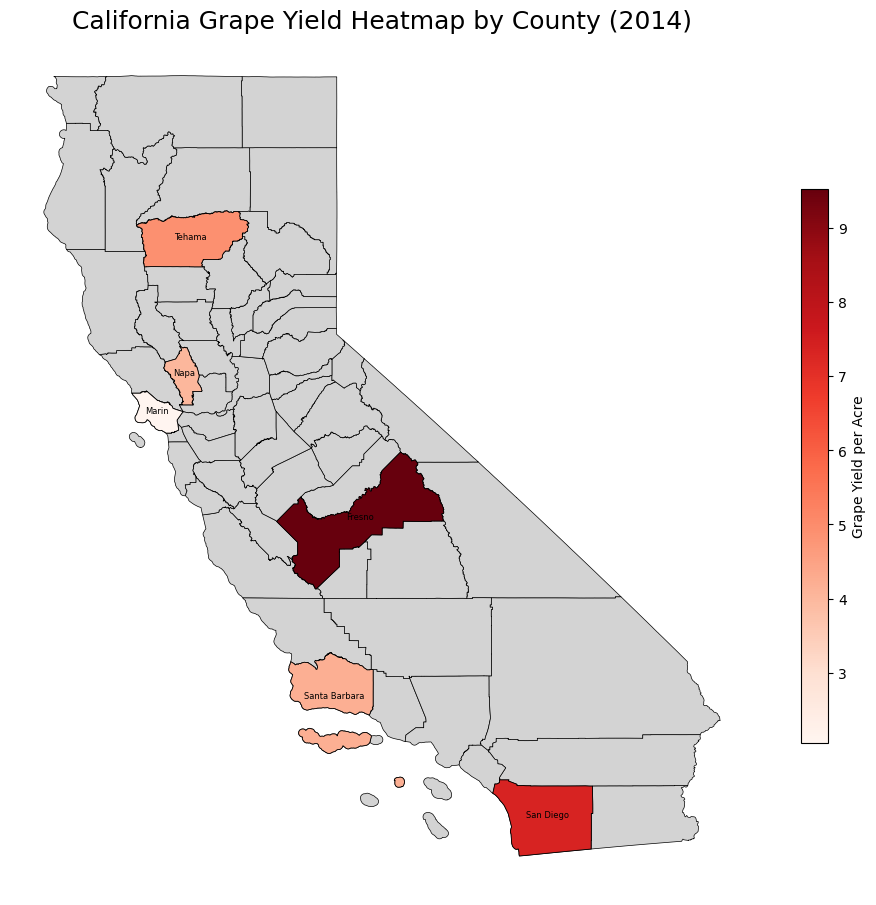

In [25]:
# 2014
# Plot heatmap
fig, ax = plt.subplots(figsize=(12,12))

# Plot all counties in grey
counties.plot(
    color="lightgrey",
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# Plot selected counties with heatmap
map_df2014.plot(
    column="yield_per_acre",
    cmap="Reds",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Grape Yield per Acre",
        "shrink": 0.6
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data"
    },
    ax=ax
)

# Add county labels
for idx, row in map_df2014.iterrows():
    if row["geometry"] is not None:
        centroid = row.geometry.centroid
        ax.text(
            centroid.x,
            centroid.y,
            row["county"],
            fontsize=6,
            ha="center"
        )

# Final styling
ax.set_title(
    "California Grape Yield Heatmap by County (2014)",
    fontsize=18
)

ax.axis("off")

plt.show()

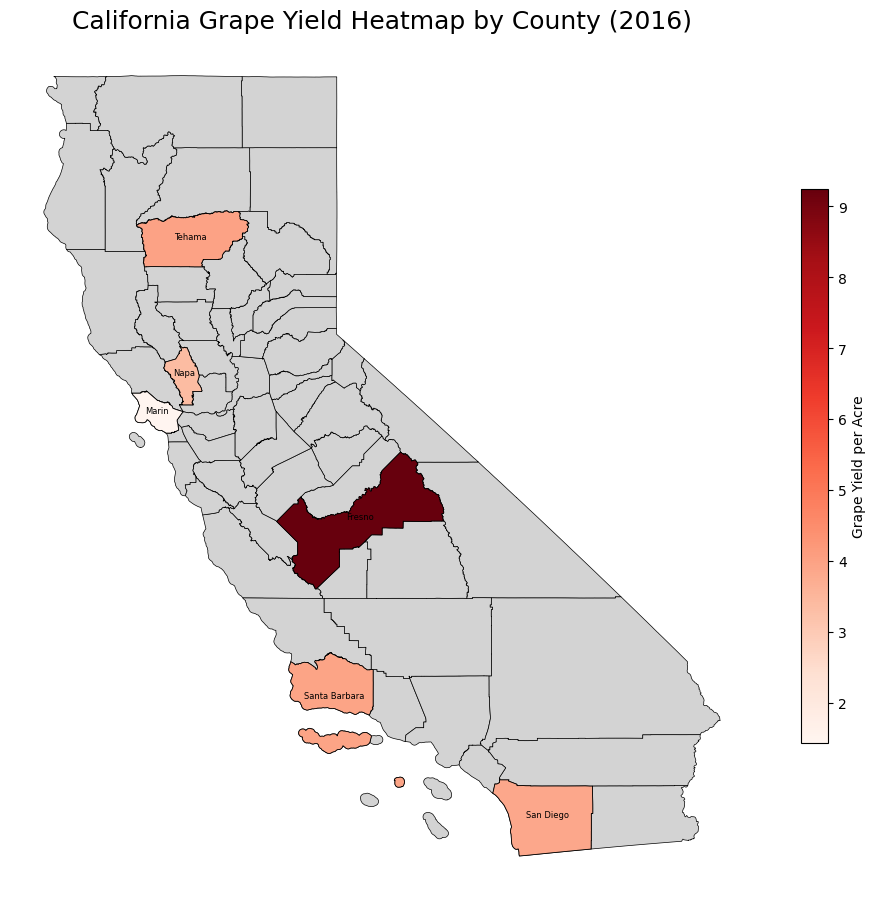

In [26]:
# 2016
# Plot heatmap
fig, ax = plt.subplots(figsize=(12,12))

# Plot all counties in grey
counties.plot(
    color="lightgrey",
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# Plot selected counties with heatmap
map_df2016.plot(
    column="yield_per_acre",
    cmap="Reds",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Grape Yield per Acre",
        "shrink": 0.6
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data"
    },
    ax=ax
)

# Add county labels
for idx, row in map_df2016.iterrows():
    if row["geometry"] is not None:
        centroid = row.geometry.centroid
        ax.text(
            centroid.x,
            centroid.y,
            row["county"],
            fontsize=6,
            ha="center"
        )

# Final styling
ax.set_title(
    "California Grape Yield Heatmap by County (2016)",
    fontsize=18
)

ax.axis("off")

plt.show()

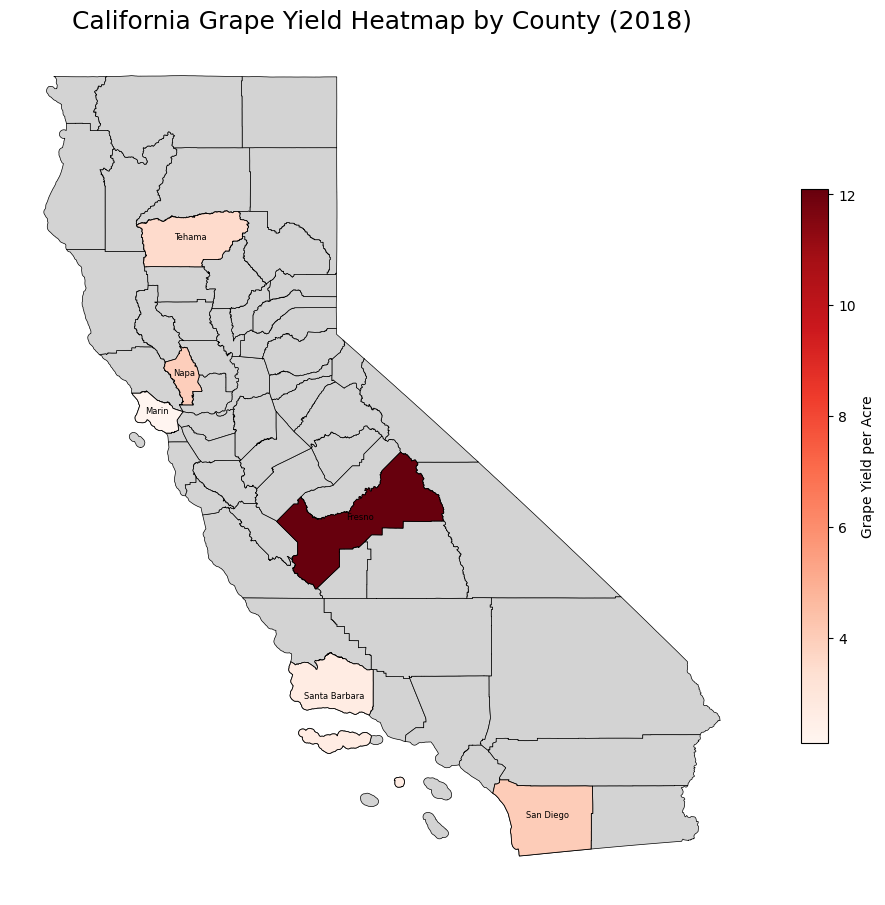

In [27]:
# 2018
# Plot heatmap
fig, ax = plt.subplots(figsize=(12,12))

# Plot all counties in grey
counties.plot(
    color="lightgrey",
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# Plot selected counties with heatmap
map_df2018.plot(
    column="yield_per_acre",
    cmap="Reds",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Grape Yield per Acre",
        "shrink": 0.6
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data"
    },
    ax=ax
)

# Add county labels
for idx, row in map_df2018.iterrows():
    if row["geometry"] is not None:
        centroid = row.geometry.centroid
        ax.text(
            centroid.x,
            centroid.y,
            row["county"],
            fontsize=6,
            ha="center"
        )

# Final styling
ax.set_title(
    "California Grape Yield Heatmap by County (2018)",
    fontsize=18
)

ax.axis("off")

plt.show()

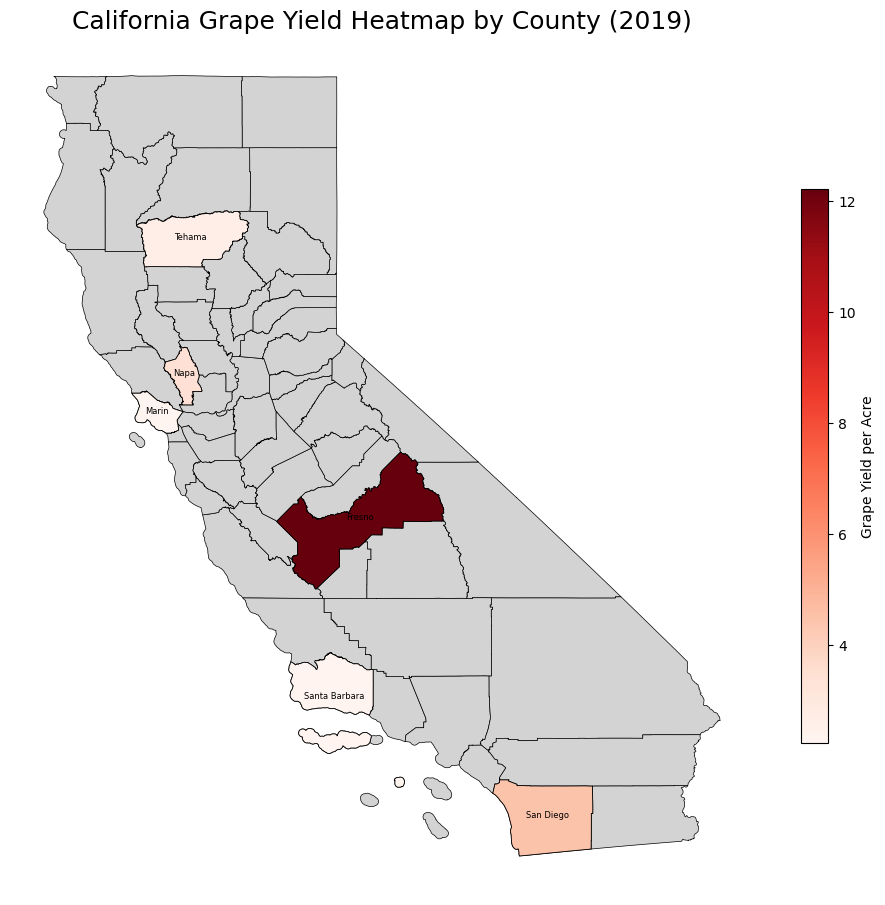

In [28]:
# 2019
# Plot heatmap
fig, ax = plt.subplots(figsize=(12,12))

# Plot all counties in grey
counties.plot(
    color="lightgrey",
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# Plot selected counties with heatmap
map_df2019.plot(
    column="yield_per_acre",
    cmap="Reds",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Grape Yield per Acre",
        "shrink": 0.6
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data"
    },
    ax=ax
)

# Add county labels
for idx, row in map_df2019.iterrows():
    if row["geometry"] is not None:
        centroid = row.geometry.centroid
        ax.text(
            centroid.x,
            centroid.y,
            row["county"],
            fontsize=6,
            ha="center"
        )

# Final styling
ax.set_title(
    "California Grape Yield Heatmap by County (2019)",
    fontsize=18
)

ax.axis("off")

plt.show()

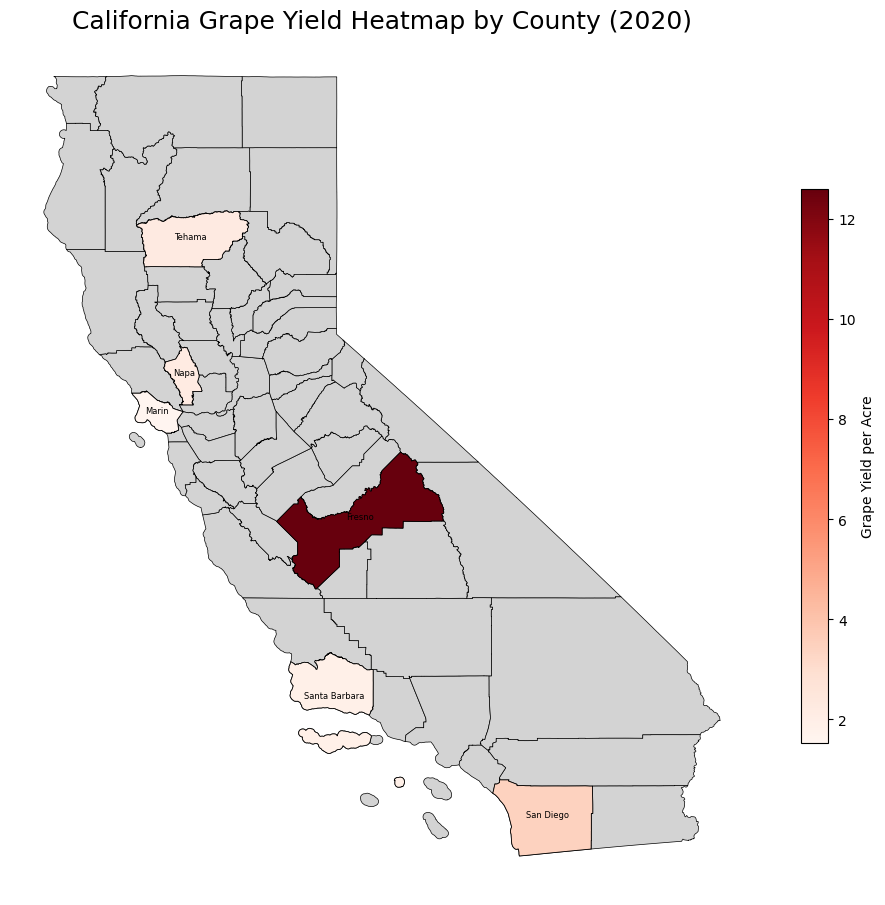

In [29]:
# 2020
# Plot heatmap
fig, ax = plt.subplots(figsize=(12,12))

# Plot all counties in grey
counties.plot(
    color="lightgrey",
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# Plot selected counties with heatmap
map_df2020.plot(
    column="yield_per_acre",
    cmap="Reds",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Grape Yield per Acre",
        "shrink": 0.6
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data"
    },
    ax=ax
)

# Add county labels
for idx, row in map_df2020.iterrows():
    if row["geometry"] is not None:
        centroid = row.geometry.centroid
        ax.text(
            centroid.x,
            centroid.y,
            row["county"],
            fontsize=6,
            ha="center"
        )

# Final styling
ax.set_title(
    "California Grape Yield Heatmap by County (2020)",
    fontsize=18
)

ax.axis("off")

plt.show()

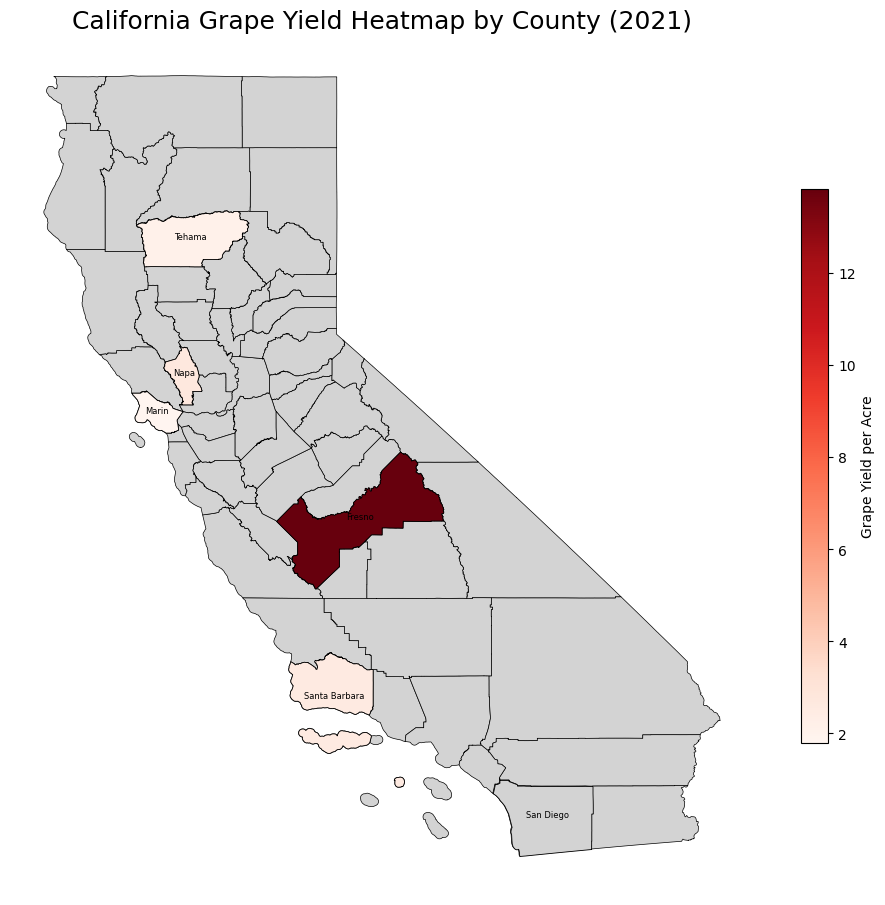

In [30]:
# 2021
# Plot heatmap
fig, ax = plt.subplots(figsize=(12,12))

# Plot all counties in grey
counties.plot(
    color="lightgrey",
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# Plot selected counties with heatmap
map_df2021.plot(
    column="yield_per_acre",
    cmap="Reds",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Grape Yield per Acre",
        "shrink": 0.6
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data"
    },
    ax=ax
)

# Add county labels
for idx, row in map_df2021.iterrows():
    if row["geometry"] is not None:
        centroid = row.geometry.centroid
        ax.text(
            centroid.x,
            centroid.y,
            row["county"],
            fontsize=6,
            ha="center"
        )

# Final styling
ax.set_title(
    "California Grape Yield Heatmap by County (2021)",
    fontsize=18
)

ax.axis("off")

plt.show()

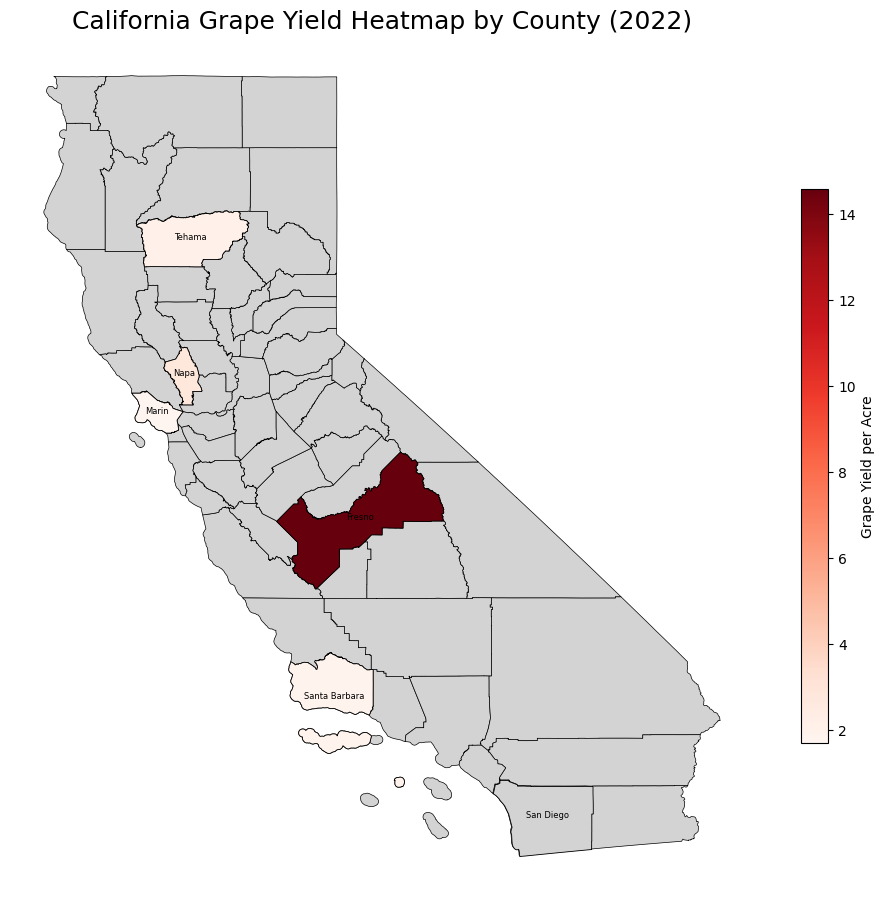

In [31]:
# 2022
# Plot heatmap
fig, ax = plt.subplots(figsize=(12,12))

# Plot all counties in grey
counties.plot(
    color="lightgrey",
    edgecolor="black",
    linewidth=0.5,
    ax=ax
)

# Plot selected counties with heatmap
map_df2022.plot(
    column="yield_per_acre",
    cmap="Reds",
    linewidth=0.6,
    edgecolor="black",
    legend=True,
    legend_kwds={
        "label": "Grape Yield per Acre",
        "shrink": 0.6
    },
    missing_kwds={
        "color": "lightgrey",
        "label": "No Data"
    },
    ax=ax
)

# Add county labels
for idx, row in map_df2022.iterrows():
    if row["geometry"] is not None:
        centroid = row.geometry.centroid
        ax.text(
            centroid.x,
            centroid.y,
            row["county"],
            fontsize=6,
            ha="center"
        )

# Final styling
ax.set_title(
    "California Grape Yield Heatmap by County (2022)",
    fontsize=18
)

ax.axis("off")

plt.show()

# CSV output

In [32]:
# Counties we want in the final output
selected_counties = [
    "Napa",
    "Santa Barbara",
    "Fresno",
    "Tehama",
    "Marin",
    "San Diego"
]

# Collect yield tables with year labels
y2014 = yield_acres2014[["county", "yield_per_acre"]].copy()
y2014["year"] = 2014

y2016 = yield_acres2016[["county", "yield_per_acre"]].copy()
y2016["year"] = 2016

y2018 = yield_acres2018[["county", "yield_per_acre"]].copy()
y2018["year"] = 2018

y2019 = yield_acres2019[["county", "yield_per_acre"]].copy()
y2019["year"] = 2019

y2020 = yield_acres2020[["county", "yield_per_acre"]].copy()
y2020["year"] = 2020

y2021 = yield_acres2021[["county", "yield_per_acre"]].copy()
y2021["year"] = 2021

y2022 = yield_acres2022[["county", "yield_per_acre"]].copy()
y2022["year"] = 2022


# Combine all years
all_years = pd.concat([
    y2014, y2016, y2018, y2019, y2020, y2021, y2022
])

# Keep only selected counties
final_df = all_years[all_years["county"].isin(selected_counties)]

# Pivot so each year is a column
final_table = final_df.pivot(
    index="county",
    columns="year",
    values="yield_per_acre"
).reset_index()

# Save to CSV
final_table.to_csv("grape_normalized_yield_selected_counties.csv", index=False)

print(final_table)

year         county      2014      2016       2018       2019       2020  \
0            Fresno  9.528942  9.251620  12.104375  12.225667  12.608704   
1             Marin  2.052027  1.435791   2.101557   2.235190   1.527884   
2              Napa  4.031724  3.377755   3.963240   3.406435   2.219983   
3         San Diego  7.341129  3.847857   4.025923   4.468275   3.436234   
4     Santa Barbara  4.187425  3.961516   2.664816   2.285581   1.900402   
5            Tehama  4.901526  3.978386   3.538619   2.644242   2.239779   

year       2021       2022  
0     13.833467  14.586747  
1      1.792873   1.701035  
2      2.715809   2.853847  
3           NaN        NaN  
4      2.552872   1.898688  
5      2.094346   2.043825  
